In [1]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

/home/wuke/anaconda3/envs/AIGEM/lib/python3.7/site-packages/Bio/pairwise2.py:283: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  BiopythonDeprecationWarning,


# input and output

# 生成数据

### 1.生成标准enzyme_counts_dict

In [2]:
AGORA2_strainlist_file = '../../Data/AGORA2_strainlist.xlsx'

In [3]:
AGORA2_strainlist = pd.read_excel(AGORA2_strainlist_file,sheet_name='Table_S1')
# AGORA2_strainlist = AGORA2_strainlist[
    # (AGORA2_strainlist['Strain/species reference'].str.contains('human gut')) 
    # |(AGORA2_strainlist['MicrobeID'].str.contains('|'.join(case_strain_list)))
# ]
# AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=1351]
# AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=562]
# AGORA2_strainlist['Genome_type'] = AGORA2_strainlist['Genome link'].apply(lambda x:x.split('//')[0])
# AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['Genome_type']=='ftp:']  
AGORA2_strainlist

,MicrobeID,PubSeedID,2 - complete comparative genomics; 1 - certain comparative genomics; 0 - no comparative genomics,Strain,Species,Genus,Family,Order,Class,Phylum,...,Motility,Sample Body Site,Sample Body Subsite,Genome Size * assembled,Gene Count * assembled,GC Count * assembled,GC * assembled,CDS Count * assembled,CDS % * assembled,Genome link
0,Abiotrophia_defectiva_ATCC_49176,Abiotrophia defectiva ATCC 49176 (592010.4),2,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva,Abiotrophia,Aerococcaceae,Lactobacillales,Bacilli,Firmicutes,...,Nonmotile,NaN,0.0,2041839.0,2009.0,959280.0,47.0,1950.0,97.06,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
1,Acaricomes_phytoseiuli_DSM_14247,Acaricomes phytoseiuli DSM 14247 (1120917.3),1,Acaricomes phytoseiuli DSM 14247,Acaricomes phytoseiuli,Acaricomes,Micrococcaceae,Micrococcales,Actinomycetia,Actinobacteria,...,Nonmotile,0.0,0.0,2419519.0,2387.0,1506904.0,62.0,2326.0,97.44,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
2,Acaryochloris_marina_MBIC11017,NaN,0,Acaryochloris marina MBIC11017,Acaryochloris marina,Acaryochloris,Acaryochloridaceae,Synechococcales,unclassified Cyanobacteria,Cyanobacteria,...,Nonmotile,0.0,0.0,8361599.0,8488.0,3926263.0,47.0,8409.0,99.07,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
3,Acetanaerobacterium_elongatum_CGMCC_1_5012,NaN,0,Acetanaerobacterium elongatum,Acetanaerobacterium elongatum,Acetanaerobacterium,Oscillospiraceae,Eubacteriales,Clostridia,Firmicutes,...,Motile,0.0,0.0,2916215.0,2842.0,1429234.0,49.0,2773.0,97.57,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...
4,Acetatifactor_muris_GP69,NaN,0,Acetatifactor muris,Acetatifactor muris,Acetatifactor,Lachnospiraceae,Eubacteriales,Clostridia,Firmicutes,...,Nonmotile,0.0,0.0,6013646.0,6002.0,2868509.0,48.0,5901.0,98.32,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7297,Yersinia_pseudotuberculosis_IP_32953,Yersinia pseudotuberculosis IP 32953 (273123.10),2,Yersinia pseudotuberculosis IP 32953,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,0,0.0,0.0,4839430.0,4363.0,2301240.0,48.0,4184.0,95.90,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
7298,Yersinia_pseudotuberculosis_PB1,Yersinia pseudotuberculosis PB1/+ (502801.6),2,Yersinia pseudotuberculosis PB1/+,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,Motile,0.0,0.0,4765387.0,4278.0,2262945.0,47.0,4105.0,95.96,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
7299,Yersinia_pseudotuberculosis_YPIII,Yersinia pseudotuberculosis YPIII (502800.6),2,Yersinia pseudotuberculosis YPIII,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,Motile,0.0,0.0,4689441.0,4298.0,2228909.0,48.0,4192.0,97.53,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...
7300,Yersinia_rohdei_ATCC_43380,Yersinia rohdei ATCC 43380 (527004.3),2,Yersinia rohdei ATCC 43380,Yersinia rohdei,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,Motile,NaN,0.0,4317478.0,3912.0,2027960.0,47.0,3853.0,98.49,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...


In [4]:
# AGORA2_strainlist[AGORA2_strainlist['Family']=='Ruminococcaceae']

# 2.统计family-level eccounts

In [5]:
# AGORA2_strainlist  = AGORA2_strainlist[AGORA2_strainlist['Family']=='Turicibacteraceae']
# AGORA2_strainlist

In [6]:
families = [
    'Turicibacteraceae',
    'Erysipelotrichaceae',
    'Rikenellaceae',
    'Ruminococcaceae'
]

genome_list = AGORA2_strainlist[AGORA2_strainlist['Family'].isin(families)]['Genome link'].dropna().tolist()
genome_list = [x.split('/')[-1] for x in genome_list if 'ftp' in x and 'GCF' in x]
genome_list

['GCF_000265365.1_ASM26536v1',
 'GCF_000321205.1_ASM32120v1',
 'GCF_000231275.1_Alis_indi_YIT_V1',
 'GCF_000311925.1_ASM31192v1',
 'GCF_000374505.1_ASM37450v1',
 'GCF_900083545.1_PRJEB13794',
 'GCF_000154465.1_ASM15446v1',
 'GCF_000312145.1_ASM31214v1',
 'GCF_000210575.1_ASM21057v1',
 'GCF_000751455.1_Alistipes_jeddahmassiliense',
 'GCF_000183485.2_ASM18348v1',
 'GCF_000285455.1_ASM28545v1',
 'GCF_000384195.1_ASM38419v1',
 'GCF_000177375.1_ASM17737v1',
 'GCF_000820765.1_Arquibacterium_massiliensis_AP7',
 'GCF_002803405.1_ASM280340v1',
 'GCF_000371425.1_Clos_inno_2959_V1',
 'GCF_002221705.2_ASM222170v2',
 'GCF_000154485.1_ASM15448v1',
 'GCF_000686665.1_ASM68666v1',
 'GCF_000154805.1_ASM15480v1',
 'GCF_000313565.1_ASM31356v2',
 'GCF_000160815.2_ASM16081v2',
 'GCF_000270085.1_ASM27008v1',
 'GCF_000404205.1_ASM40420v1',
 'GCF_000225685.1_Erys_bact_2_2_44A_V1',
 'GCF_000242195.1_Erys_bact_21_3_V1',
 'GCF_000163515.2_Ery_bact_5_2_54FAA_V2',
 'GCF_000242175.1_Erys_bact_6_1_45_V1',
 'GCF_00168

In [7]:
strain_eccounts = {}

clean_result_folder = '/home/wuke/project/bio_deeplearning/Z-Benchmark-EC_predict/CLEAN-0205/app/results/'

for index, row in tqdm(AGORA2_strainlist.iterrows(), total=len(AGORA2_strainlist)):
    ncbiID = row['Genome link'].split('/')[-1]  # 提取 NCBI ID
    strain_family = row['Family']
    strain_species = row['Species']
    clean_result_file = os.path.join(clean_result_folder, f"{ncbiID}_clean_result.json")

    if not os.path.exists(clean_result_file):
        continue  # 如果文件不存在，跳过

    with open(clean_result_file, 'r', encoding='utf-8') as f:
        clean_result = json.load(f)
    # # 预处理 clean_result：保留前三位的 EC 号
    # # clean_result = {k: ['.'.join(x.split('.')[0:3]) for x in v] for k, v in clean_result.items()}
    if strain_family not in strain_eccounts:
        strain_eccounts[strain_family] = {}
    species_ec_list= []
    for gene,ec_list in clean_result.items():
        for ec in ec_list:
            if ec not in species_ec_list:
                species_ec_list.append(ec)
            else:
                pass
    if strain_species not in strain_eccounts[strain_family]:
        strain_eccounts[strain_family][strain_species] = []
        strain_eccounts[strain_family][strain_species].append(len(set(species_ec_list)))
    else:
        strain_eccounts[strain_family][strain_species].append(len(set(species_ec_list)))

100%|██████████| 7302/7302 [02:17<00:00, 53.20it/s] 


In [8]:
ncbiID = 'GCF_000178255.1_ASM17825v1'
clean_result_file = os.path.join(clean_result_folder, f"{ncbiID}_clean_result.json")

if not os.path.exists(clean_result_file):
    print('error')

with open(clean_result_file, 'r', encoding='utf-8') as f:
    clean_result = json.load(f)
clean_result


{'WP_006783172.1': ['1.20.4.1'],
 'WP_006783173.1': ['1.8.1.8'],
 'WP_006783174.1': ['1.3.7.3'],
 'WP_006783175.1': ['2.7.7.88', '2.1.1.375'],
 'WP_006783176.1': ['2.5.1.2', '2.2.1.1'],
 'WP_006783177.1': ['2.4.1.129'],
 'WP_006783178.1': ['2.4.1.129'],
 'WP_006783179.1': ['7.6.2.11'],
 'WP_006783180.1': ['1.11.1.23'],
 'WP_006783181.1': ['5.2.1.8'],
 'WP_006783182.1': ['3.6.5.n1'],
 'WP_006783183.1': ['3.6.4.12'],
 'WP_006783185.1': ['3.6.4.12'],
 'WP_006783188.1': ['2.7.13.3'],
 'WP_006783189.1': ['4.2.1.131'],
 'WP_006783190.1': ['2.3.1.57'],
 'WP_006783191.1': ['4.2.3.26'],
 'WP_006783192.1': ['1.12.1.2'],
 'WP_006783193.1': ['3.1.1.61'],
 'WP_006783194.1': ['1.7.1.17', '1.5.1.38'],
 'WP_006783195.1': ['7.6.2.2'],
 'WP_006783196.1': ['2.4.1.16', '2.7.13.3'],
 'WP_006783197.1': ['3.4.13.19'],
 'WP_006783198.1': ['2.3.1.57'],
 'WP_006783199.1': ['3.1.1.32', '3.1.1.4'],
 'WP_006783200.1': ['1.5.3.1'],
 'WP_006783201.1': ['2.7.13.3'],
 'WP_006783202.1': ['2.1.1.98', '2.1.1.151', '2.1.1

In [9]:
from statistics import mean

strain_eccounts_filter = {}
for family, ec_counts in strain_eccounts.items():
    # 提取出所有非空列表的长度并取平均，然后再对这些平均值取平均
    family_means = [mean(ec_num_list) for ec_num_list in ec_counts.values() if len(ec_num_list) > 0]
    if family_means:  # 确保该科下有有效数据
        strain_eccounts_filter[family] = family_means

In [10]:
strain_eccounts_filter

{'Aerococcaceae': [1007, 828, 1010],
 'Micrococcaceae': [1266, 1375, 1325, 1140, 1031],
 'Acaryochloridaceae': [702],
 'Oscillospiraceae': [814,
  1550,
  1415,
  1439,
  1289,
  1290,
  1417,
  1407,
  1298,
  1358,
  1315],
 'Lachnospiraceae': [1617,
  1818,
  1834.4,
  1773,
  1390,
  1534,
  1139,
  1260,
  1223,
  1273,
  1482,
  1381,
  1320,
  1115,
  1112],
 'Sporomusaceae': [759],
 'Alcaligenaceae': [2114, 1810],
 'Eubacteriales Family XII. Incertae Sedis': [1441],
 'Acidaminococcaceae': [1178, 1097, 1139],
 'Acidobacteriaceae': [1542],
 'Comamonadaceae': [1534, 1862.5, 2048],
 'Moraxellaceae': [1534.3450704225352,
  1557,
  1556.125,
  1506,
  1378.75,
  1423.6666666666667,
  1378.5,
  1364.5,
  1538.5,
  1377.1666666666667,
  936,
  1574,
  1573,
  1552,
  1550,
  980.3333333333334],
 'Pasteurellaceae': [1122.4285714285713,
  1130,
  983.5,
  1000.9230769230769,
  1082.3333333333333,
  1076],
 'Actinomycetaceae': [1014,
  1032,
  1355,
  1000,
  1166,
  1394.5,
  1382,
  100

In [11]:
family_list =  {
    # 'Enterococcaceae':0,
    'Streptococcaceae': 3.1,
    'Turicibacteraceae': 3.1,
    'Enterobacteriaceae': 3.1,
    'Alcaligenaceae': 3.4,
    'Veillonellaceae': 3.8,
    'Peptostreptococcaceae': 4.1,
    'Porphyromonadaceae': 4.2,
    'Erysipelotrichaceae': 4.5,
    'Clostridiaceae': 4.5,
    'Bifidobacteriaceae': 5.0,
    'Rikenellaceae': 5.3,
    'Bacteroidaceae': 10.0,
    'Ruminococcaceae': 32.0,
    'Lachnospiraceae': 34.0
}

In [12]:
strain_eccounts_filter = {family:ec for family,ec in strain_eccounts_filter.items() if family in family_list}
len(strain_eccounts_filter)

14

In [13]:
strain_eccounts_filter

{'Lachnospiraceae': [1617,
  1818,
  1834.4,
  1773,
  1390,
  1534,
  1139,
  1260,
  1223,
  1273,
  1482,
  1381,
  1320,
  1115,
  1112],
 'Alcaligenaceae': [2114, 1810],
 'Rikenellaceae': [1055,
  1162,
  1214,
  1357,
  1076,
  1334,
  1283,
  1345,
  1163,
  1272,
  1146],
 'Bacteroidaceae': [1462,
  1719,
  1371,
  1606,
  1462.5,
  1451,
  1551.375,
  1587,
  1649.75,
  1580,
  1412.5,
  1600,
  1515.2,
  1531.5,
  1399,
  1582],
 'Bifidobacteriaceae': [1059,
  964.8,
  1052,
  1045,
  1173.3333333333333,
  1088.7142857142858],
 'Erysipelotrichaceae': [789,
  1132,
  1466,
  1225,
  1155,
  1033,
  1283,
  850,
  1464,
  1147,
  1400,
  1335,
  1106,
  930,
  1032,
  1348,
  1345,
  1178,
  1080,
  1039.5,
  1323,
  1053],
 'Ruminococcaceae': [1101, 1195],
 'Enterobacteriaceae': [1821,
  1714.2857142857142,
  1911,
  1769,
  1850.5,
  1816,
  1808,
  1661,
  1826.1210855949896,
  1765,
  1772,
  1783,
  1823,
  1742,
  1754,
  1815.5,
  2042.3333333333333,
  2091,
  1959.075,


In [14]:
# ===== 核心逻辑：按 family_list 重新排列并填充缺失值 =====
sorted_data = {}

for family in family_list:
    # 尝试从原始数据中获取该菌科的数据
    if family in strain_eccounts_filter:
        sorted_data[family] = strain_eccounts_filter[family]

# 打印结果查看
sorted_data

{'Streptococcaceae': [987.9,
  1133.2,
  1096.6666666666667,
  1007.6478873239437,
  948,
  986,
  973.8,
  925.6666666666666,
  1065.3333333333333,
  978,
  885,
  924.6666666666666,
  948.5,
  961.7128712871287,
  963.7142857142857,
  976.25,
  1019.5,
  988.972972972973,
  982.75,
  1092.9,
  880.4,
  920],
 'Turicibacteraceae': [1218, 1055, 1232],
 'Enterobacteriaceae': [1821,
  1714.2857142857142,
  1911,
  1769,
  1850.5,
  1816,
  1808,
  1661,
  1826.1210855949896,
  1765,
  1772,
  1783,
  1823,
  1742,
  1754,
  1815.5,
  2042.3333333333333,
  2091,
  1959.075,
  1780,
  1989,
  1776.1962025316457,
  1571.75,
  1621.076923076923],
 'Alcaligenaceae': [2114, 1810],
 'Veillonellaceae': [1071.5, 1079.5],
 'Peptostreptococcaceae': [1392.7058823529412, 972],
 'Porphyromonadaceae': [928, 1011.5],
 'Erysipelotrichaceae': [789,
  1132,
  1466,
  1225,
  1155,
  1033,
  1283,
  850,
  1464,
  1147,
  1400,
  1335,
  1106,
  930,
  1032,
  1348,
  1345,
  1178,
  1080,
  1039.5,
  1323,

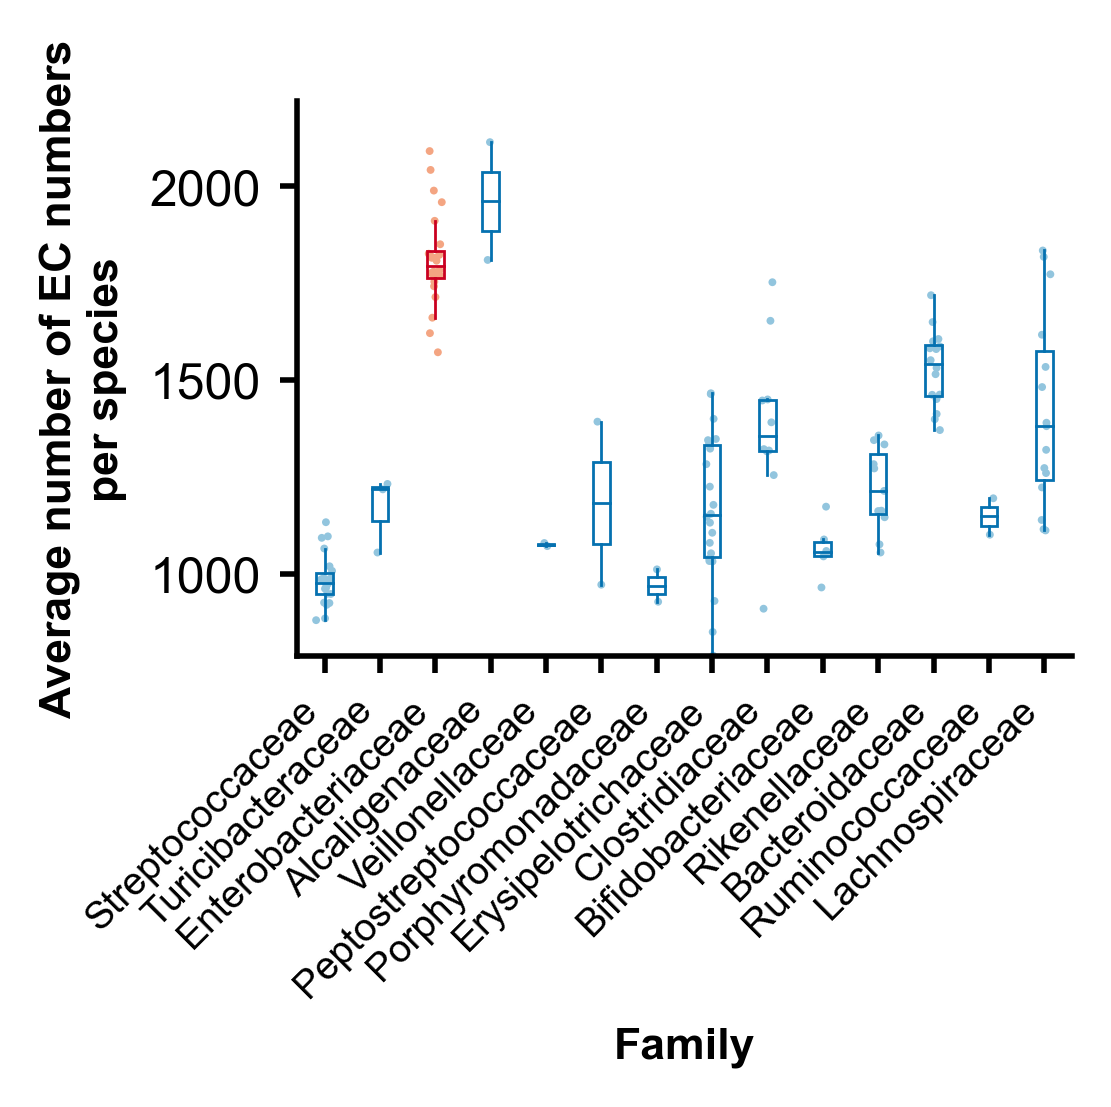

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 sorted_data 是你上一步处理好的字典（包含填充了随机数的数据）
raw_data = sorted_data 

# ===== 数据预处理 =====
rate_labels = list(raw_data.keys())
data = list(raw_data.values())
positions = list(range(1, len(rate_labels) + 1))

# ===== 全局设置（统一风格）=====
np.random.seed(0)

fig, ax = plt.subplots(figsize=(2.5, 1.8), dpi=400)

plt.rcParams.update({'font.size': 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# ===== 定义颜色 =====
default_box_color = '#0571b0'   # 默认箱子线条颜色
default_dot_color = '#92c5de'   # 默认散点颜色
special_box_color = '#ca0020'   # 第3个箱子线条颜色
special_dot_color = '#f4a582'   # 第3个散点颜色

# ===== boxplot =====
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    showcaps=False
)

# ===== 设置箱线图样式（加入第3个高亮判断）=====
for i, patch in enumerate(bp['boxes']):
    current_box_color = special_box_color if i == 2 else default_box_color
    patch.set_facecolor('none')
    patch.set_edgecolor(current_box_color)
    patch.set_linewidth(0.5)

# 须线 (whiskers) 是成对出现的
for i in range(0, len(bp['whiskers']), 2):
    current_box_color = special_box_color if i // 2 == 2 else default_box_color
    bp['whiskers'][i].set_color(current_box_color)
    bp['whiskers'][i].set_linewidth(0.5)
    bp['whiskers'][i+1].set_color(current_box_color)
    bp['whiskers'][i+1].set_linewidth(0.5)

# 中位数线 (medians)
for i, median in enumerate(bp['medians']):
    current_box_color = special_box_color if i == 2 else default_box_color
    median.set_color(current_box_color)
    median.set_linewidth(0.5)

# ===== 绘制抖动散点（加入第3个高亮判断 + 修复单点报错）=====
for i, group in enumerate(data):
    group_len = len(group)
    # 如果只有1个数据，不加随机抖动，避免 numpy 报错
    if group_len > 1:
        x_jittered = positions[i] + np.random.normal(0, 0.06, size=group_len)
    else:
        x_jittered = [positions[i]]
    
    # 判断当前是不是第3组数据（索引为2）
    current_dot_color = special_dot_color if i == 2 else default_dot_color
    
    ax.scatter(
        x_jittered,
        group,
        color=current_dot_color,
        edgecolors='none',
        s=2,
        zorder=1,
        alpha=1
    )

# ===== 坐标轴 =====
ax.set_xticks(positions)
ax.set_xticklabels(rate_labels, fontsize=7, rotation=45, ha='right')

ax.set_xlabel('Family', fontsize=8, fontweight='bold')
ax.set_ylabel('Average number of EC numbers\nper species', fontsize=8, fontweight='bold')

# ===== tick风格（统一规范）=====
ax.tick_params(axis='y', direction='out', width=1, length=3)
ax.tick_params(axis='x', direction='out', width=1, length=3)

# ===== 边框 =====
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# 自动调整Y轴范围，并稍微留出一点顶部空间
ax.autoscale(enable=True, axis='y', tight=True)
current_ylim = ax.get_ylim()
ax.set_ylim(current_ylim[0], current_ylim[1] * 1.05)

# 调整底部边距，防止X轴标签被截断
# plt.subplots_adjust(left=0.13, right=0.95, bottom=0.28, top=0.92)


# plt.savefig('../../Figure/Figure-S8.pdf', dpi=400, bbox_inches='tight')
plt.savefig('../../Figure/Figure-S10.tiff',dpi=400,bbox_inches='tight',format='tiff')
plt.show()

Arial


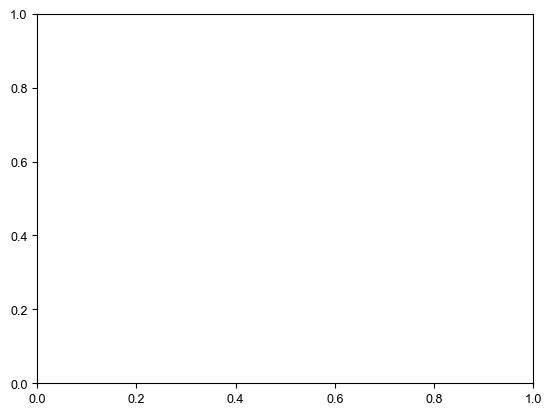

In [16]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots()

print(ax.xaxis.label.get_fontproperties().get_name())

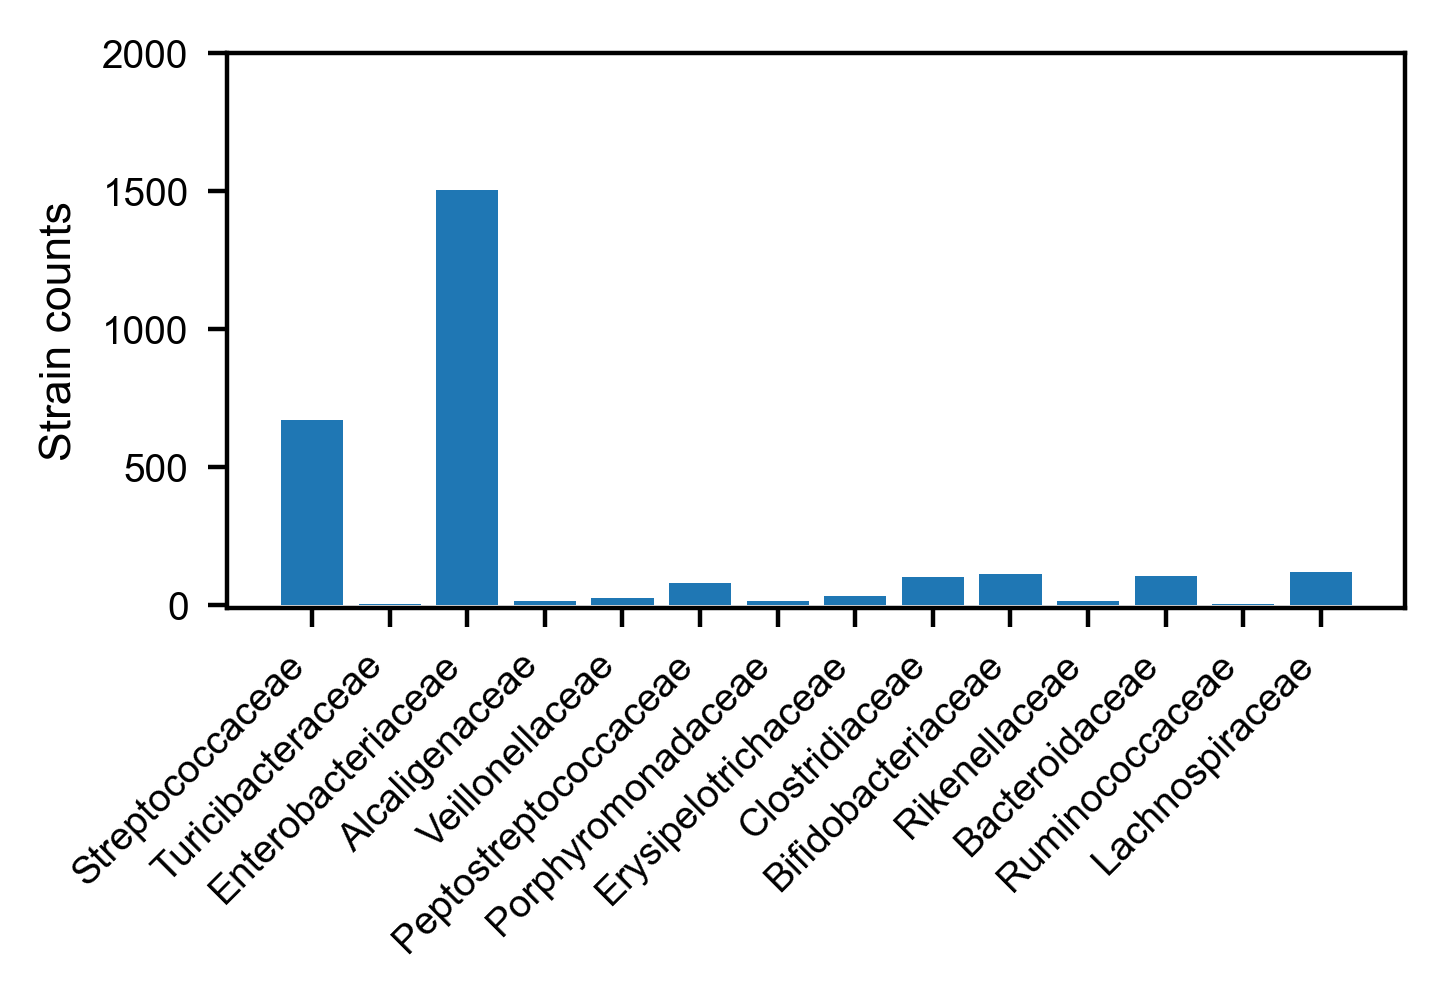

In [17]:
import matplotlib.pyplot as plt

# 如果你环境支持，可以加这个（论文PDF常用）
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

family_strain_counts = {
    'Enterobacteriaceae': 1503,
    'Streptococcaceae': 670,
    'Enterococcaceae': 482,
    'Lachnospiraceae': 120,
    'Bifidobacteriaceae': 110,
    'Bacteroidaceae': 105,
    'Clostridiaceae': 101,
    'Peptostreptococcaceae': 79,
    'Erysipelotrichaceae': 31,
    'Veillonellaceae': 26,
    'Porphyromonadaceae': 13,
    'Rikenellaceae': 13,
    'Alcaligenaceae': 13,
    'Turicibacteraceae': 3,
    'Ruminococcaceae': 2
}

family_list = {
    'Streptococcaceae': 3.1,
    'Turicibacteraceae': 3.1,
    'Enterobacteriaceae': 3.1,
    'Alcaligenaceae': 3.4,
    'Veillonellaceae': 3.8,
    'Peptostreptococcaceae': 4.1,
    'Porphyromonadaceae': 4.2,
    'Erysipelotrichaceae': 4.5,
    'Clostridiaceae': 4.5,
    'Bifidobacteriaceae': 5.0,
    'Rikenellaceae': 5.3,
    'Bacteroidaceae': 10.0,
    'Ruminococcaceae': 32.0,
    'Lachnospiraceae': 34.0
}

# 按 family_list 顺序筛选
ordered_keys = [k for k in family_list.keys() if k in family_strain_counts]
values = [family_strain_counts[k] for k in ordered_keys]

plt.figure(figsize=(3.8, 1.8), dpi=400)

plt.bar(ordered_keys, values)

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.ylabel("Strain counts", fontsize=8)

# plt.tight_layout()
plt.ylim(-10,2000)
plt.show()